# DeepFashion2 – Data Preprocessing

This notebook:
1. Unzips the dataset from Kaggle input
2. Counts category frequencies and picks Top-5
3. Prunes + splits into train/val/test
4. Creates the `MultiLabelDataset` and DataLoaders for classification

**Run this notebook first** before any model notebook.

## 1. Setup – Kaggle Paths

In [1]:
import os

# Kaggle: No drive mount needed. Data is available at /kaggle/input/
# Output directory: /kaggle/working/
KAGGLE_INPUT = "/kaggle/input/datasets/sasank93/vr-mini-project-1/VR_Mini_project_data"   # adjust to your dataset slug
WORKING      = "/kaggle/working"
os.makedirs(f"{WORKING}/VR_Mini_Project-1", exist_ok=True)
SAVE_DIR     = f"{WORKING}/VR_Mini_Project-1"import json

metadata = {
    "title": "VR Mini Project Pruned Dataset",
    "id": "sasank93/vr-mini-project-pruned",  # change if needed
    "licenses": [{"name": "CC0-1.0"}]
}

with open(f"{DATASET_DIR}/dataset-metadata.json", "w") as f:
    json.dump(metadata, f)
print("Save dir:", SAVE_DIR)

Save dir: /kaggle/working/VR_Mini_Project-1


## 3. Count Category Frequencies

In [2]:
import os
import json
from collections import defaultdict
from tqdm import tqdm

anno_path = f"{KAGGLE_INPUT}/train/annos"
category_count = defaultdict(int)

id_to_name_map = {}

for file in tqdm(os.listdir(anno_path)):
    with open(os.path.join(anno_path, file)) as f:
        data = json.load(f)

        for key in data:
            if key.startswith("item"):
                cat_id = data[key]["category_id"]
                category_count[cat_id] += 1

                cat_name = data[key].get("category_name", "Unknown Category")
                if cat_id not in id_to_name_map:
                    id_to_name_map[cat_id] = cat_name

# Sort categories by frequency
sorted_counts = sorted(category_count.items(), key=lambda x: x[1], reverse=True)

print("Category Frequencies:")
for cat_id, count in sorted_counts:
    cat_name = id_to_name_map[cat_id]
    print(f"ID {cat_id} ({cat_name}): {count}")

100%|██████████| 191961/191961 [24:30<00:00, 130.51it/s]

Category Frequencies:
ID 1 (short sleeve top): 71645
ID 8 (trousers): 55387
ID 7 (shorts): 36616
ID 2 (long sleeve top): 36064
ID 9 (skirt): 30835
ID 12 (vest dress): 17949
ID 10 (short sleeve dress): 17211
ID 5 (vest): 16095
ID 4 (long sleeve outwear): 13457
ID 11 (long sleeve dress): 7907
ID 13 (sling dress): 6492
ID 6 (sling): 1985
ID 3 (short sleeve outwear): 543


## 4. Visualize Distribution

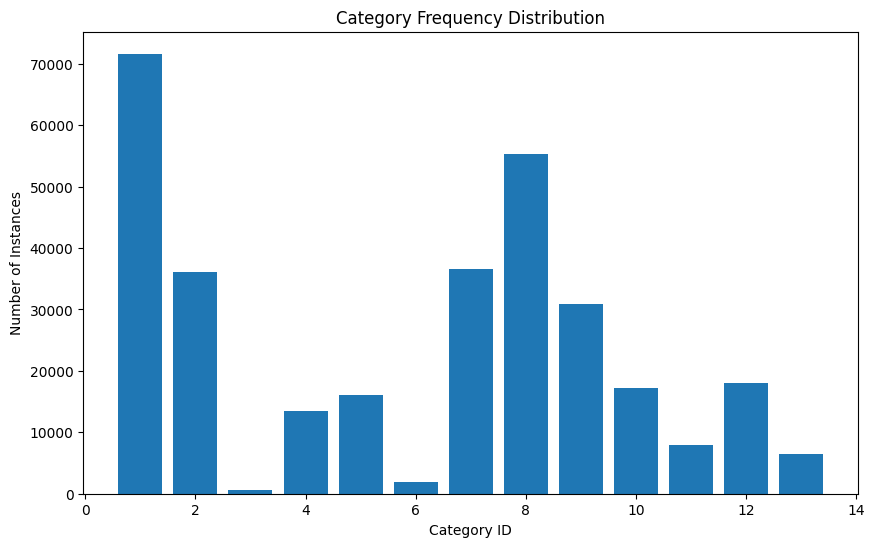

In [3]:
import matplotlib.pyplot as plt

cats = [x[0] for x in sorted_counts]
counts = [x[1] for x in sorted_counts]

plt.figure(figsize=(10,6))
plt.bar(cats, counts)
plt.xlabel("Category ID")
plt.ylabel("Number of Instances")
plt.title("Category Frequency Distribution")
plt.show()

## 5. Compute Coverage of Top 5

In [4]:
total_instances = sum(counts)
top5_instances = sum(counts[:5])

print("Total instances:", total_instances)
print("Top 5 instances:", top5_instances)
print("Coverage %:", (top5_instances / total_instances) * 100)

Total instances: 312186
Top 5 instances: 230547
Coverage %: 73.84924372008994


## 6. Define Top-5 Categories

In [5]:
TOP5 = [1, 8, 7, 2, 9]

## 7. Create Pruned Dataset Folders

In [6]:
import os
import json
import shutil
import random
from tqdm import tqdm

TOP5 = [1, 8, 7, 2, 9]

def process_dataset(orig_img_dir, orig_anno_dir, new_img_dir, new_anno_dir):
    """Prunes a dataset directory to only include images with TOP5 categories."""
    os.makedirs(new_img_dir, exist_ok=True)
    os.makedirs(new_anno_dir, exist_ok=True)

    kept_images = 0

    # Process annotations and copy corresponding images
    for file in tqdm(os.listdir(orig_anno_dir), desc=f"Processing {os.path.basename(orig_img_dir)}"):
        if not file.endswith('.json'): continue

        with open(os.path.join(orig_anno_dir, file)) as f:
            data = json.load(f)

        new_data = {}
        instance_id = 1

        # Filter items by category
        for key in data:
            if key.startswith("item"):
                cat_id = data[key]["category_id"]
                if cat_id in TOP5:
                    new_data[f"item{instance_id}"] = data[key]
                    instance_id += 1

        # If the image has at least one valid item, keep it
        if len(new_data) > 0:
            with open(os.path.join(new_anno_dir, file), "w") as f:
                json.dump(new_data, f)

            img_name = file.replace(".json", ".jpg")
            shutil.copy(os.path.join(orig_img_dir, img_name), os.path.join(new_img_dir, img_name))
            kept_images += 1

    return kept_images

# --- 1. Prune the Training Data ---
print("Pruning Training Data...")
print(process_dataset(f"{KAGGLE_INPUT}/train/image", f"{KAGGLE_INPUT}/train/annos", "/kaggle/working/pruned_train/images", "/kaggle/working/pruned_train/annos"))

# --- 2. Prune the Validation Data ---
print("\nPruning Validation Data...")
print(process_dataset(f"{KAGGLE_INPUT}/validation/image", f"{KAGGLE_INPUT}/validation/annos", "/kaggle/working/pruned_val/images", "/kaggle/working/pruned_val/annos"))


# --- 3. Create Local Test Set from Pruned Train Set ---
print("\nCreating Local Test Set from Training Data...")
train_img_dir = "/kaggle/working/pruned_train/images"
train_anno_dir = "/kaggle/working/pruned_train/annos"
test_img_dir = "/kaggle/working/pruned_test/images"
test_anno_dir = "/kaggle/working/pruned_test/annos"

os.makedirs(test_img_dir, exist_ok=True)
os.makedirs(test_anno_dir, exist_ok=True)

# Grab all pruned training images
all_train_images = [f for f in os.listdir(train_img_dir) if f.endswith('.jpg')]

# Shuffle with a seed for reproducibility
random.seed(42)
random.shuffle(all_train_images)

# Calculate the 15% split
split_index = int(len(all_train_images) * 0.85)
test_images = all_train_images[split_index:]

# Move files from the pruned train folder to the new test folder
for img_name in tqdm(test_images, desc="Moving files to test set"):
    anno_name = img_name.replace(".jpg", ".json")

    shutil.move(os.path.join(train_img_dir, img_name), os.path.join(test_img_dir, img_name))
    shutil.move(os.path.join(train_anno_dir, anno_name), os.path.join(test_anno_dir, anno_name))

Pruning Training Data...


Processing image: 100%|██████████| 191961/191961 [47:23<00:00, 67.50it/s]  


144174

Pruning Validation Data...


Processing image: 100%|██████████| 32153/32153 [08:53<00:00, 60.21it/s]


23741

Creating Local Test Set from Training Data...


Moving files to test set: 100%|██████████| 21627/21627 [00:02<00:00, 9708.20it/s] 


## 8. Label Mapping

In [7]:
TOP5 = [1, 8, 7, 2, 9]
category_names = ['Short Sleeve Top', 'Trousers', 'Shorts', 'Long Sleeve Top', 'Skirt']
cat_to_idx = {cat_id: i for i, cat_id in enumerate(TOP5)}
idx_to_cat = {i: cat_id for cat_id, i in cat_to_idx.items()}

print("Index → Category:", idx_to_cat)

Index → Category: {0: 1, 1: 8, 2: 7, 3: 2, 4: 9}


## Creating Kaggle dataset

In [8]:
!pip install -q kaggle

In [9]:
import os
import shutil

DATASET_DIR = "/kaggle/working/VR_MP_Pruned"
os.makedirs(DATASET_DIR, exist_ok=True)

# Copy all your folders into one place
shutil.copytree("/kaggle/working/pruned_train", f"{DATASET_DIR}/pruned_train")
shutil.copytree("/kaggle/working/pruned_test", f"{DATASET_DIR}/pruned_test")
shutil.copytree("/kaggle/working/pruned_val", f"{DATASET_DIR}/pruned_val")

'/kaggle/working/VR_MP_Pruned/pruned_val'

In [12]:
import json

metadata = {
    "title": "VR_Mini_Project_Pruned_Dataset",
    "id": "sasank93/vr-mini-project-pruned",  # change if needed
    "licenses": [{"name": "CC0-1.0"}],
    "visibility": "public"
}

with open(f"{DATASET_DIR}/dataset-metadata.json", "w") as f:
    json.dump(metadata, f)

In [15]:
!kaggle datasets create -p /kaggle/working/VR_MP_Pruned --dir-mode zip

Starting upload for file pruned_train.zip
100%|██████████████████████████████████████| 6.32G/6.32G [03:34<00:00, 31.7MB/s]
Upload successful: pruned_train.zip (6GB)
Starting upload for file pruned_val.zip
100%|██████████████████████████████████████| 1.23G/1.23G [00:43<00:00, 30.6MB/s]
Upload successful: pruned_val.zip (1GB)
Starting upload for file pruned_test.zip
100%|██████████████████████████████████████| 1.11G/1.11G [00:39<00:00, 30.4MB/s]
Upload successful: pruned_test.zip (1GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/sasank93/vr-mini-project-pruned
